In [29]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import utils

In [30]:
df = pd.read_csv("combined_data_clean.csv")
df.shape[0]

3863

In [31]:
df.columns

Index(['FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HST', 'AST', 'B365H', 'B365A',
       'BWH', 'BWA', 'PSH', 'PSA', 'WHH', 'WHA', 'MaxH', 'MaxA', 'AvgH',
       'AvgA', 'AHh', 'B365CH', 'B365CA', 'BWCH', 'PSCH', 'PSCA', 'WHCH',
       'MaxCH', 'MaxCA', 'AvgCH', 'AvgCA', 'AHCh', 'IWH', 'IWA', 'VCH', 'VCA'],
      dtype='object')

In [32]:
betting_keywords = ['B365', 'BW', 'PS', 'WH', 'Max', 'Avg', 'VC', 'IW', 'AH']

df = df.drop(
    columns=[c for c in df.columns if any(k in c for k in betting_keywords)]
)

df.columns

Index(['FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HST', 'AST'], dtype='object')

In [33]:
rename_map = {
    'FTHG': 'Full Time Home Goals',
    'FTAG': 'Full Time Away Goals',
    'FTR' : 'Full Time Result',
    'HTHG': 'Half Time Home Goals',
    'HTAG': 'Half Time Away Goals',
    'HST' : 'Home Shots on Target',
    'AST' : 'Away Shots on Target'
}
df = df.rename(columns=rename_map)
df.columns



Index(['Full Time Home Goals', 'Full Time Away Goals', 'Full Time Result',
       'Half Time Home Goals', 'Half Time Away Goals', 'Home Shots on Target',
       'Away Shots on Target'],
      dtype='object')

In [34]:
from sklearn.preprocessing import LabelEncoder

X = df[
    [
        'Half Time Home Goals',
        'Half Time Away Goals',
        'Home Shots on Target',
        'Away Shots on Target'
    ]
]

y = df['Full Time Result']

encoder = LabelEncoder()
y = encoder.fit_transform(y)   # H / D / A → 0 / 1 / 2


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
# after transformation mean = 0 , sd = 1.
X_train = scaler.fit_transform(X_train)
# transform using the same fit learned earlier.
X_test = scaler.transform(X_test)

In [36]:
# from sklearn.svm import SVC
# from sklearn.model_selection import GridSearchCV

# param_grid = [
#     {'kernel': ['linear'], 'C': [0.01, 0.1, 1, 10, 100]},
#     {'kernel': ['poly'], 'C': [0.01, 0.1, 1, 10, 100], 'degree': [2, 3, 4, 5]}
# ]

# grid_search = GridSearchCV(
#     SVC(random_state=42),
#     param_grid,
#     cv=5,       # 5-fold cross-validation
#     scoring='accuracy',
#     n_jobs=-1   # use all cores
# )

# grid_search.fit(X_train, y_train)

# print("Best params:", grid_search.best_params_)
# print("Best CV Accuracy:", grid_search.best_score_)


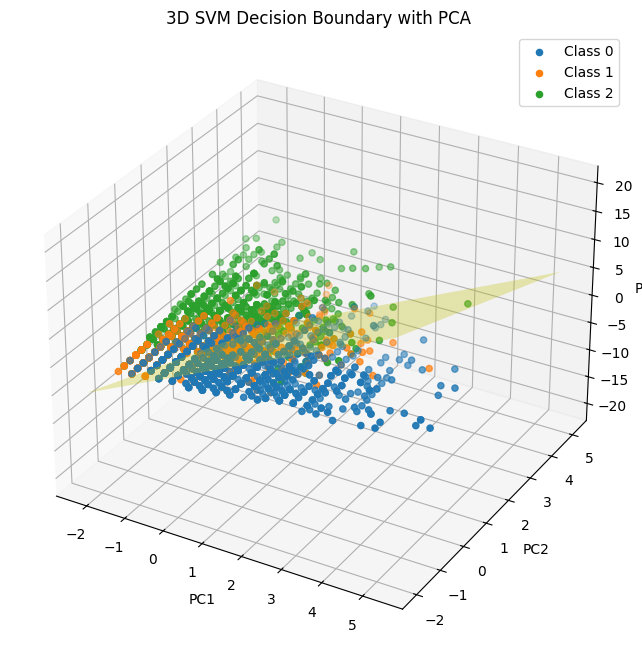

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# Reduce features to 3D
pca = PCA(n_components=3)
features_3d = pca.fit_transform(X_train)
labels = y_train

# Train linear SVM on the 3 principal components
svm_3d = SVC(kernel='linear', C=1.0)
svm_3d.fit(features_3d, labels)

# Create interactive 3D plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Plot the points by class
for class_value in np.unique(labels):
    ax.scatter(
        features_3d[labels==class_value, 0],
        features_3d[labels==class_value, 1],
        features_3d[labels==class_value, 2],
        label=f'Class {class_value}',
        s=20
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()

# Create a meshgrid to visualize the SVM decision plane
# Note: For 3D, we can only plot the plane for 2 variables at a time, fixing the third
xx, yy = np.meshgrid(
    np.linspace(features_3d[:,0].min(), features_3d[:,0].max(), 20),
    np.linspace(features_3d[:,1].min(), features_3d[:,1].max(), 20)
)

# Plane equation for linear SVM: w0*x + w1*y + w2*z + b = 0 → solve for z
w = svm_3d.coef_[0]
b = svm_3d.intercept_[0]
zz = (-w[0]*xx - w[1]*yy - b) / w[2]

ax.plot_surface(xx, yy, zz, alpha=0.3, color='yellow')

plt.title("3D SVM Decision Boundary with PCA")
plt.show()


In [38]:
from sklearn.svm import SVC

svm = SVC(
    kernel='linear',
    # Regularization parameter: higher C → less misclassification
    C=1.0,
    # Whether to enable shrinking heuristic
    shrinking=False,
    # Random seed for probability estimates or tie-breaking
    random_state=42
)

# Train the model
svm.fit(X_train, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,False
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [39]:
print("Accuracy:", svm.score(X_train, y_train))

Accuracy: 0.6453074433656958


In [40]:
# Accuracy For Test

from sklearn.metrics import accuracy_score, classification_report

y_pred = svm.predict(X_test)

print("SVM Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Away Win', 'Draw', 'Home Win']
    )
)

SVM Accuracy: 0.64
              precision    recall  f1-score   support

    Away Win       0.67      0.71      0.69       236
        Draw       0.42      0.29      0.34       200
    Home Win       0.70      0.80      0.75       337

    accuracy                           0.64       773
   macro avg       0.60      0.60      0.59       773
weighted avg       0.62      0.64      0.63       773



In [46]:
# Accuracy For Train
from sklearn.metrics import accuracy_score, classification_report

# Predict on training set
y_pred_train = svm.predict(X_train)

print("SVM Train Accuracy:", round(accuracy_score(y_train, y_pred_train), 2))
print(
    classification_report(
        y_train,
        y_pred_train,
        target_names=['Away Win', 'Draw', 'Home Win']
    )
)


SVM Train Accuracy: 0.65
              precision    recall  f1-score   support

    Away Win       0.66      0.68      0.67       869
        Draw       0.46      0.34      0.39       822
    Home Win       0.71      0.80      0.75      1399

    accuracy                           0.65      3090
   macro avg       0.61      0.61      0.60      3090
weighted avg       0.63      0.65      0.63      3090



In [42]:
import joblib
joblib.dump(svm, "svm.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']